ACID stands for Atomicity, Consistency, Isolation,
 and Durability.

 Atomicity ensures that a transaction is treated as
 a single, indivisible unit. It either fully completes
 or leaves no trace in the database.

 Consistency ensures that a transaction takes the
 database from one consistent state to another. It
 must satisfy all integrity constraints.

 Isolation ensures that concurrent transactions do
 not interfere with each other, and their effects
 appear as if they occurred serially.
 
 Durability guarantees that once a transaction is
 committed, its changes are permanent and will
 survive system crashes

Atomicity

Ensures that a transaction is treated as a single, indivisible unit. If any part of the transaction fails, the entire transaction is rolled back.

Example: Transferring money from one account to another.

In [1]:
# Database schema
accounts = {
    'account1': 1000,
    'account2': 500
}

# Transaction
def transfer_money(from_account, to_account, amount):
    try:
        # Subtract amount from from_account
        accounts[from_account] -= amount
        
        # Add amount to to_account
        accounts[to_account] += amount
        
        # Commit transaction
        print("Transaction committed")
    except Exception as e:
        # Rollback transaction
        accounts[from_account] += amount
        accounts[to_account] -= amount
        print("Transaction rolled back")
        print(str(e))

transfer_money('account1', 'account2', 200)

Transaction committed


In [2]:
accounts

{'account1': 800, 'account2': 700}

Consistency

Ensures that the database remains in a consistent state, even after multiple transactions.

Example: Ensuring that the total balance of all accounts remains the same after a transfer.

In [3]:
# Database schema
accounts = {
    'account1': 1000,
    'account2': 500
}

# Transaction
def transfer_money(from_account, to_account, amount):
    try:
        # Check if from_account has sufficient balance
        if accounts[from_account] < amount:
            raise ValueError("Insufficient balance")
        
        # Subtract amount from from_account
        accounts[from_account] -= amount
        
        # Add amount to to_account
        accounts[to_account] += amount
        
        # Commit transaction
        print("Transaction committed")
    except Exception as e:
        # Rollback transaction
        print("Transaction rolled back")
        print(str(e))

transfer_money('account1', 'account2', 200)

Transaction committed


In [4]:
accounts

{'account1': 800, 'account2': 700}

isolation

Ensures that multiple transactions can execute concurrently without interfering with each other.

Example: Using locks to prevent concurrent transactions from accessing the same data.

In [5]:
import threading

# Database schema
accounts = {
    'account1': 1000,
    'account2': 500
}

# Locks
locks = {
    'account1': threading.Lock(),
    'account2': threading.Lock()
}

# Transaction
def transfer_money(from_account, to_account, amount):
    try:
        # Acquire locks
        locks[from_account].acquire()
        locks[to_account].acquire()
        
        # Subtract amount from from_account
        accounts[from_account] -= amount
        
        # Add amount to to_account
        accounts[to_account] += amount
        
        # Commit transaction
        print("Transaction committed")
    except Exception as e:
        # Rollback transaction
        print("Transaction rolled back")
        print(str(e))
    finally:
        # Release locks
        locks[from_account].release()
        locks[to_account].release()

# Create threads for concurrent transactions
thread1 = threading.Thread(target=transfer_money, args=('account1', 'account2', 200))
thread2 = threading.Thread(target=transfer_money, args=('account2', 'account1', 100))

# Start threads
thread1.start()
thread2.start()

# Wait for threads to finish
thread1.join()
thread2.join()

Transaction committed
Transaction committed


In [6]:
accounts

{'account1': 900, 'account2': 600}

Durability

Ensures that once a transaction is committed, its effects are permanent and survive even in the event of a system failure.

Example: Using a transaction log to record changes made by a transaction.

In [7]:
# Database schema
accounts = {
    'account1': 1000,
    'account2': 500
}

# Transaction log
transaction_log = []

# Transaction
def transfer_money(from_account, to_account, amount):
    try:
        # Record transaction in log
        transaction_log.append((from_account, to_account, amount))
        
        # Subtract amount from from_account
        accounts[from_account] -= amount
        
        # Add amount to to_account
        accounts[to_account] += amount
        
        # Commit transaction
        print("Transaction committed")
    except Exception as e:
        # Rollback transaction
        print("Transaction rolled back")
        print(str(e))

transfer_money('account1', 'account2', 200)

# Save transaction log to disk
with open('transaction_log.txt', 'w') as f:
    for transaction in transaction_log:
        f.write(str(transaction) + '\n')

Transaction committed


In [8]:
accounts

{'account1': 800, 'account2': 700}

What is normalization, and why is it important in
 DBMS?
 
 Ans:
 Normalization is the process of organizing data in a
 database to reduce data redundancy and improve
 data integrity.
 It involves dividing large tables into smaller, related
 tables and defining relationships between them. 
Normalization helps in eliminating data anomalies
 like insertion, update, and deletion anomalies,
 making the database more efficient and
 maintainable

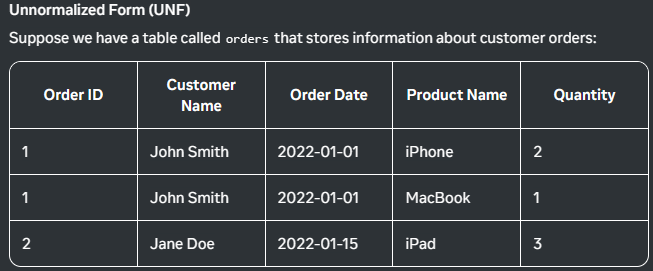

This table is unnormalized because it contains redundant data (Customer Name) and has a multi-valued attribute (Product Name and Quantity).

In [ ]:
CREATE TABLE customers (
    Customer ID INT PRIMARY KEY,
    Customer Name VARCHAR(50)
);

CREATE TABLE orders (
    Order ID INT PRIMARY KEY,
    Customer ID INT,
    Order Date DATE,
    FOREIGN KEY (Customer ID) REFERENCES customers(Customer ID)
);

CREATE TABLE order_items (
    Order ID INT,
    Product Name VARCHAR(50),
    Quantity INT,
    FOREIGN KEY (Order ID) REFERENCES orders(Order ID)
);

'CREATE TABLE customers (\n    Customer ID INT PRIMARY KEY,\n    Customer Name VARCHAR(50)\n);\n\nCREATE TABLE orders (\n    Order ID INT PRIMARY KEY,\n    Customer ID INT,\n    Order Date DATE,\n    FOREIGN KEY (Customer ID) REFERENCES customers(Customer ID)\n);\n\nCREATE TABLE order_items (\n    Order ID INT,\n    Product Name VARCHAR(50),\n    Quantity INT,\n    FOREIGN KEY (Order ID) REFERENCES orders(Order ID)\n);'

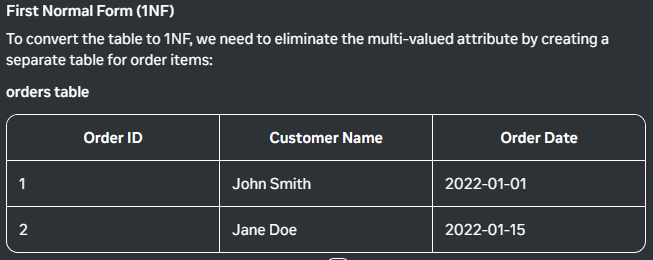

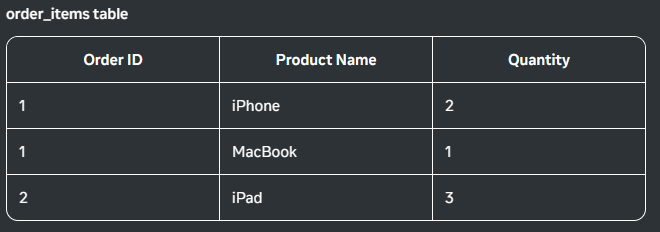

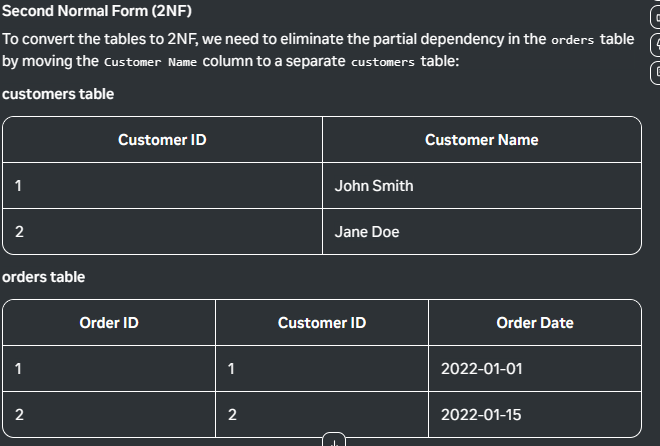

Use normalization when data integrity is a top
 priority, and use denormalization when you need to
 optimize query performance

database normalization is the process of organizing the data in a database to minimize data redundancy and dependency

 A primary key is a unique identifier for a record in
 a table. It ensures that each row in the table is
 uniquely identifiable. There can be only one
 primary key per table.
 
 A foreign key is a field in a table that is used to
 establish a link between two tables. It creates a
 relationship between the tables by referencing
 the primary key of another table. It enforces
 referential integrity

What is indexing in DBMS, and why is it
 important?
 Ans:
 
 Indexing is a technique used to optimize the retrieval
 of records from a database table. It involves creating
 a data structure that provides fast access to rows
 based on one or more columns.
 
 Indexes improve query performance by reducing the
 number of records that need to be scanned. They are
 important for efficient data retrieval in large
 databases


Indexing in DBMS is a data structure technique used to improve the speed of data retrieval operations

Creating an Index

Suppose we have a table called employees with columns employee_id, name, age, and department:

In [ ]:
CREATE TABLE employees (
    employee_id INT PRIMARY KEY,
    name VARCHAR(50),
    age INT,
    department VARCHAR(50)
);

To create an index on the department column, we can use the following SQL command:


In [ ]:
CREATE INDEX idx_department ON employees (department);

'CREATE INDEX idx_department ON employees (department);'

B-Tree Indexing Binary Search

B-Tree indexing is a popular indexing technique used in many DBMS systems. Here's an example of how B-Tree indexing works:

Suppose we have a table called employees with columns employee_id, name, age, and department, and we want to create a B-Tree index on the department column:

In [ ]:
CREATE TABLE employees (
    employee_id INT PRIMARY KEY,
    name VARCHAR(50),
    age INT,
    department VARCHAR(50)
);

CREATE INDEX idx_department ON employees (department) USING BTREE;

Hash Indexing

Hash indexing is another indexing technique used in DBMS systems. Here's an example of how hash indexing works:

Suppose we have a table called employees with columns employee_id, name, age, and department, and we want to create a hash index on the department column:

In [ ]:
CREATE TABLE employees (
    employee_id INT PRIMARY KEY,
    name VARCHAR(50),
    age INT,
    department VARCHAR(50)
);

CREATE INDEX idx_department ON employees (department) USING HASH;

Creating an index on a column used in the WHERE clause of a query.
Creating an index on a column used in the JOIN clause of a query.
Creating an index on a column used in the ORDER BY clause of a query.

In [ ]:
CREATE TABLE orders (
    order_id INT PRIMARY KEY,
    customer_id INT,
    order_date DATE,
    total DECIMAL(10, 2)
);

CREATE INDEX idx_customer_id ON orders (customer_id);

SELECT * FROM orders WHERE customer_id = 123;

the index on the customer_id column can speed up the query that retrieves all orders for a specific customer.

the difference between a clustered
 and a non-clustered index?

 Ans:
 A clustered index determines the physical order of
 data rows in a table. There can be only one
 clustered index per table, and it directly affects the
 way data is stored on disk.

In [ ]:
CREATE TABLE employees (
    employee_id INT PRIMARY KEY CLUSTERED,
    name VARCHAR(50),
    age INT,
    department VARCHAR(50)
);




 
 A non-clustered index does not dictate the physical
 order of data. It creates a separate data structure
 that provides a quick lookup to the actual data
 rows. Multiple non-clustered indexes can exist on a
 table

In [ ]:
CREATE TABLE employees (
    employee_id INT PRIMARY KEY,
    name VARCHAR(50),
    age INT,
    department VARCHAR(50)
);

CREATE NONCLUSTERED INDEX idx_department ON employees (department);

clustered indexes are used to store the data in a specific order, while non-clustered indexes create a separate data structure that contains the index keys and pointers to the corresponding rows in the table.

Data concurrency

 control is a mechanism to manage
 simultaneous access to the database by multiple
 users or transactions. It ensures that transactions do
 not interfere with each other and maintain data
 consistency. Techniques like locking, timestamping,
 and multiversion concurrency control are used to
 achieve this

Data concurrency control in DBMS refers to the techniques used to manage multiple transactions that access shared data simultaneously. The goal of concurrency control is to ensure that the database remains in a consistent state, even when multiple transactions are executed concurrently.

Locking: This technique involves locking the data items that are being accessed by a transaction. Other transactions that try to access the locked data items are blocked until the lock is released.

Timestamping: This technique involves assigning a timestamp to each transaction. The transaction with the earliest timestamp is executed first.

Optimistic Concurrency Control: This technique involves assuming that multiple transactions can execute concurrently without conflicts. If a conflict occurs, the transaction is rolled back and restarted.

Pessimistic Concurrency Control: This technique involves assuming that multiple transactions will conflict with each other. The transaction that accesses the data first locks the data items to prevent other transactions from accessing them.

Shared Locks: A shared lock allows multiple transactions to read the data items simultaneously.
Exclusive Locks: An exclusive lock allows only one transaction to write to the data items.
Intent Locks: An intent lock indicates that a transaction intends to access the data items

Two-Phase Locking (2PL): This algorithm involves two phases: expanding and shrinking. During the expanding phase, the transaction acquires locks on the data items. During the shrinking phase, the transaction releases locks on the data items.

Multiple Granularity Locking (MGL): This algorithm involves locking data items at multiple levels of granularity.

Concurrency Control:

Suppose we have two transactions, T1 and T2, that access the same data item, X.

In [ ]:
T1: READ X
T1: X = X + 10
T1: WRITE X

T2: READ X
T2: X = X + 20
T2: WRITE X

Without concurrency control,the transactions may interfere with each other, resulting in incorrect results. With concurrency control, the transactions are executed in a way that ensures the database remains in a consistent state.
For example, using locking, T1 may acquire an exclusive lock on X, preventing T2 from accessing X until T1 releases the lock.

In [ ]:
T1: LOCK X (EXCLUSIVE)
T1: READ X
T1: X = X + 10
T1: WRITE X
T1: UNLOCK X

T2: LOCK X (EXCLUSIVE)
T2: READ X
T2: X = X + 20
T2: WRITE X
T2: UNLOCK X

 database
 and a DBMS?
 
 Ans:
 A database is a structured collection of data, while a
 DBMS (Database Management System) is software
 that facilitates the storage, retrieval, and
 management of data in a database.
 The DBMS provides tools and services to interact
 with the data stored in the database

 A deadlock
 
  occurs when two or more transactions
 are unable to proceed because each is waiting for a
 resource that the other holds.

 Deadlocks can be prevented using techniques like
 locking protocols, timeouts, or resource allocation
 strategies.
 
 They can also be resolved using deadlock detection
 and resolution algorithms

transaction log in a

 DBMS.
 Ans:
 A transaction log is a record of all changes made to a
 database during transactions. It includes information
 about the beginning and end of transactions, as well
 as details about data modifications.
 Transaction logs are essential for recovering a
 database to a consistent state after system failures
 and for maintaining data integrity

query optimizer in a
 DBMS?
 
 Ans:
 A query optimizer is a component of a DBMS that is
 responsible for determining the most efficient way
 to execute a database query.
 It analyzes various query execution plans and selects
 the one with the lowest cost in terms of I/O, CPU, or
 other resources. The goal is to optimize query
 performance

 A heap file
 
  organization is an unstructured
 storage approach where records are inserted
 wherever there is space in the file. It is simple but
 can lead to fragmentation and slower retrieval
 times.

 A clustered
 
  file organization organizes records in
 a specific order based on the values of one or
 more columns. It can provide faster retrieval for
 certain types of queries but may be less flexible
 than a heap file

 The transaction manager
 
  in a DBMS is responsible
 for managing the execution of transactions and
 ensuring they adhere to the ACID properties.
 It does this by coordinating transaction execution,
 maintaining a transaction log, and using techniques
 like locking and rollback to guarantee atomicity,
 consistency, isolation, and durability.

Database normalization

 forms are a series of
 guidelines used to eliminate data redundancy and
 improve data integrity.

 1NF (First Normal Form): Ensures that each
 column contains only atomic (indivisible) values.

 2NF (Second Normal Form): Requires 1NF and
 that all non-key attributes are fully functionally
 dependent on the primary key.
 
 3NF (Third Normal Form): Requires 2NF and that
 there are no transitive dependencies between
 non-key attributes.

A database

 is a collection of data stored in an
 organized manner, 

 while a schema
 
  is a logical
 container within a database that defines the
 structure and organization of the data, including
 tables, relationships, and constraints.

Referential integrity

 is a constraint that ensures the
 consistency of relationships between tables.
 It requires that foreign key values in one table match
 primary key values in another table.
 This constraint prevents the creation of orphaned
 records and maintains data integrity

A B-tree

 index is a type of index structure that
 organizes data in a balanced tree-like structure. It
 is suitable for range queries and sorting, and it
 maintains data in a sorted order.

 A hash 
 
 index is a data structure that uses a hash
 function to map keys to locations in a table. It is
 efficient for equality queries but not well-suited
 for range queries or sorting

A database transaction

 log records all changes made
 to the database during transactions.
 It plays a crucial role in disaster recovery by allowing
 the system to restore the database to a consistent
 state after a failure.
 By replaying the log, the DBMS can recover changes
 up to the point of failure.

Data warehousing 

involves the process of collecting,
 storing, and managing large volumes of data from
 various sources into a centralized repository called a
 data warehouse.
 The data is then organized, transformed, and
 optimized for analytical and reporting purposes.
 Data warehousing facilitates business intelligence
 and data analysis

Horizontal scaling

 a database involves distributing data across multiple machines to handle increased load efficiently. This is commonly achieved through 
 
 sharding, 
 
 replication, and 
 
 load balancing. 
 
 Here's a simple implementation using MongoDB (NoSQL) and PostgreSQL (SQL) with horizontal scaling techniques.

What is Sharding?


Sharding is a database architecture pattern that horizontally partitions data across multiple servers (shards) to improve performance, scalability, and availability. Each shard contains a subset of the data, and queries are distributed based on a defined sharding key.

Example: Sharding in MongoDB

MongoDB provides built-in support for sharding. We will:

Set up a sharded cluster with config servers, shard servers, and a router (mongos).

Enable sharding on a collection.

Insert data and observe automatic distribution across shards.


The config server stores metadata about the shards.

In [ ]:
mongod --configsvr --replSet configReplSet --port 27019 --dbpath /data/configdb --fork --logpath /data/configdb.log

Initialize the replica set in the MongoDB shell:

In [ ]:
rs.initiate({_id: "configReplSet", configsvr: true, members: [{ _id: 0, host: "localhost:27019" }]})

start Shard Servers

Each shard is an independent replica set.

Start Shard 1

In [ ]:
mongod --shardsvr --replSet shard1ReplSet --port 27018 --dbpath /data/shard1 --fork --logpath /data/shard1.log

Initialize the shard in MongoDB shell:

In [ ]:
rs.initiate({_id: "shard1ReplSet", members: [{ _id: 0, host: "localhost:27018" }]})

Start Shard 2

In [ ]:
mongod --shardsvr --replSet shard2ReplSet --port 27020 --dbpath /data/shard2 --fork --logpath /data/shard2.log

Initialize the shard:

In [ ]:
rs.initiate({_id: "shard2ReplSet", members: [{ _id: 0, host: "localhost:27020" }]})

Start Mongos Router

The mongos process acts as a query router that forwards queries to the appropriate shard.

In [ ]:
mongos --configdb configReplSet/localhost:27019 --port 27017 --fork --logpath /data/mongos.log

Add shards to the cluster in MongoDB shell:

In [ ]:
sh.addShard("shard1ReplSet/localhost:27018")
sh.addShard("shard2ReplSet/localhost:27020")

Enable Sharding on a Database

Enable sharding for the database:

In [ ]:
use ecommerce

sh.enableSharding("ecommerce")

Shard a collection (e.g., users) based on user_id:

In [ ]:
sh.shardCollection("ecommerce.users", { user_id: "hashed" });

This distributes the users collection across multiple shards based on a hashed user_id

Insert Data

In [ ]:
db.users.insertMany([
  { user_id: 1, name: "Alice", email: "alice@example.com" },
  { user_id: 2, name: "Bob", email: "bob@example.com" },
  { user_id: 3, name: "Charlie", email: "charlie@example.com" },
]);

Check where data is stored using:

In [ ]:
db.users.getShardDistribution();

It will show how data is distributed among shards.

Sharding in PostgreSQL

PostgreSQL doesn’t support automatic sharding, but partitioning and foreign data wrappers (FDW) can simulate sharding.

Create a Parent Table

In [ ]:
CREATE TABLE users (
    user_id SERIAL PRIMARY KEY,
    name TEXT NOT NULL,
    email TEXT NOT NULL
) PARTITION BY HASH (user_id);

Create Shards (Partitions)

In [ ]:
CREATE TABLE users_shard_0 PARTITION OF users
    FOR VALUES WITH (MODULUS 2, REMAINDER 0);
    
CREATE TABLE users_shard_1 PARTITION OF users
    FOR VALUES WITH (MODULUS 2, REMAINDER 1);

modulo operator

shard 0 store even userid

shard 1 store odd userid

 Insert Data

In [ ]:
INSERT INTO users (user_id, name, email) VALUES (1, 'Alice', 'alice@example.com');
INSERT INTO users (user_id, name, email) VALUES (2, 'Bob', 'bob@example.com');

PostgreSQL automatically distributes data based on the user_id modulo operation.

Sharding + Replication in MongoDB

Each shard should be a replica set, ensuring high availability

The config server stores metadata for shards.
Run the following on each config server node:

In [ ]:
mongod --configsvr --replSet configReplSet --port 27019 --dbpath /data/config1 --fork --logpath /data/config1.log
mongod --configsvr --replSet configReplSet --port 27029 --dbpath /data/config2 --fork --logpath /data/config2.log
mongod --configsvr --replSet configReplSet --port 27039 --dbpath /data/config3 --fork --logpath /data/config3.log


Initialize the Config Replica Set (on any one node)

In [ ]:
rs.initiate({
    _id: "configReplSet",
    configsvr: true,
    members: [
        { _id: 0, host: "localhost:27019" },
        { _id: 1, host: "localhost:27029" },
        { _id: 2, host: "localhost:27039" }
    ]
})

Start Shards (With Replication)

Shard 1 (Replica Set)

Start three shard servers for redundancy:

In [ ]:
mongod --shardsvr --replSet shard1ReplSet --port 27018 --dbpath /data/shard1a --fork --logpath /data/shard1a.log
mongod --shardsvr --replSet shard1ReplSet --port 27028 --dbpath /data/shard1b --fork --logpath /data/shard1b.log
mongod --shardsvr --replSet shard1ReplSet --port 27038 --dbpath /data/shard1c --fork --logpath /data/shard1c.log

Initialize the Shard 1 Replica Set:

In [ ]:
rs.initiate({
    _id: "shard1ReplSet",
    members: [
        { _id: 0, host: "localhost:27018" },
        { _id: 1, host: "localhost:27028" },
        { _id: 2, host: "localhost:27038" }
    ]
})

Shard 2 (Replica Set)

Start three servers for Shard 2

In [ ]:
mongod --shardsvr --replSet shard2ReplSet --port 27020 --dbpath /data/shard2a --fork --logpath /data/shard2a.log
mongod --shardsvr --replSet shard2ReplSet --port 27030 --dbpath /data/shard2b --fork --logpath /data/shard2b.log
mongod --shardsvr --replSet shard2ReplSet --port 27040 --dbpath /data/shard2c --fork --logpath /data/shard2c.log

Initialize the Shard 2 Replica Set:

In [ ]:
rs.initiate({
    _id: "shard2ReplSet",
    members: [
        { _id: 0, host: "localhost:27020" },
        { _id: 1, host: "localhost:27030" },
        { _id: 2, host: "localhost:27040" }
    ]
})


Start mongos Router

The mongos router acts as the entry point for clients, distributing queries to shards.

In [ ]:
mongos --configdb configReplSet/localhost:27019,localhost:27029,localhost:27039 --port 27017 --fork --logpath /data/mongos.log

Add Shards to Cluster

In MongoDB shell, connect to mongos and register the shards:

In [ ]:
sh.addShard("shard1ReplSet/localhost:27018,localhost:27028,localhost:27038")
sh.addShard("shard2ReplSet/localhost:27020,localhost:27030,localhost:27040")

Enable Sharding on a Collection

In [ ]:
use ecommerce
sh.enableSharding("ecommerce")
sh.shardCollection("ecommerce.orders", { "order_id": "hashed" })

Verify Load Distribution

In [ ]:
db.orders.insertMany([
  { order_id: 1, user_id: 101, total: 150 },
  { order_id: 2, user_id: 102, total: 200 },
  { order_id: 3, user_id: 103, total: 300 },
]);

Check distribution across shards:

In [ ]:
db.orders.getShardDistribution();

Load Balancing Queries Across MongoDB Shards

To balance queries, we use multiple mongos routers and a load balancer like HAProxy.

Start Multiple Mongos Instances

In [ ]:
mongos --configdb configReplSet/localhost:27019,localhost:27029,localhost:27039 --port 27050 --fork --logpath /data/mongos1.log
mongos --configdb configReplSet/localhost:27019,localhost:27029,localhost:27039 --port 27051 --fork --logpath /data/mongos2.log

Configure HAProxy for Load Balancing

Edit /etc/haproxy/haproxy.cfg:

In [ ]:
frontend mongo_frontend
    bind *:27017
    default_backend mongo_backend

backend mongo_backend
    balance roundrobin
    server mongos1 127.0.0.1:27050 check
    server mongos2 127.0.0.1:27051 check

Restart HAProxy:

In [ ]:
sudo systemctl restart haproxy

all client connections to port 27017 will be load-balanced across the mongos routers!

PostgreSQL Sharding with Citus (For Load Balancing)

PostgreSQL can be sharded using Citus, an open-source extension.

Install Citus

In [ ]:
sudo apt install postgresql-15-citus

Enable Citus:

In [ ]:
CREATE EXTENSION citus;

Create Distributed Table

In [ ]:
SELECT create_distributed_table('orders', 'order_id');

Add Worker Nodes

In [ ]:
SELECT * from citus_add_node('worker1', 5433);
SELECT * from citus_add_node('worker2', 5434);

Insert Data and Distribute

In [ ]:
INSERT INTO orders (order_id, user_id, total) VALUES (1, 101, 150);

Data is now sharded and distributed across multiple worker nodes!